# A Gallery of Classical Walking Linkages

Leggedsnake ships **one-call factories** for the canonical planar leg
mechanisms, each preloaded with its published (or published-equivalent)
link lengths. This notebook walks through every factory, plots the foot
trajectory for one full crank revolution, and flags the design
trade-offs that distinguish each family.

**What you'll learn:**
- Building a `Walker` from a factory (`Walker.from_jansen()`, `from_klann()`, ...)
- Extracting the foot locus with `walker.step()` and `extract_trajectory()`
- Reading a foot curve as a walking-gait diagnostic
- Picking between four-bar, six-bar, and eight-bar topologies


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

import leggedsnake as ls
from pylinkage import extract_trajectory

warnings.filterwarnings('ignore', category=DeprecationWarning)


## 1. A helper: foot locus of any Walker

Every `Walker` has a cached `Mechanism`. Its joints are in solve order;
`walker.get_feet()` returns the node IDs that the kinematic solver
detected as feet (terminal or outermost driven nodes). We look those
IDs up in `mechanism.joints` to pull the right trajectory.


In [2]:
def foot_loci(walker, iterations=None):
    # Return list of (foot_name, xs, ys) for one full crank revolution.
    mech = walker.to_mechanism()
    loci = list(walker.step(iterations=iterations))
    feet_ids = set(walker.get_feet())
    out = []
    for i, joint in enumerate(mech.joints):
        name = getattr(joint, 'name', '') or ''
        # Factories name feet like "G (foot)" — match by prefix.
        if name in feet_ids or any(name.startswith(fid + ' ') for fid in feet_ids):
            xs, ys = extract_trajectory(loci, i)
            if xs.size:
                out.append((name, xs, ys))
    return out


## 2. Theo Jansen's 8-bar (the holy number)

Jansen's linkage is an 8-bar mechanism tuned over 40 years of
experimentation. Its defining property is a **flat bottom** on the foot
curve — the foot glides horizontally during stance, keeping the body
level.


DOF: 17, feet: ['C', 'D', 'E', 'F', 'G']


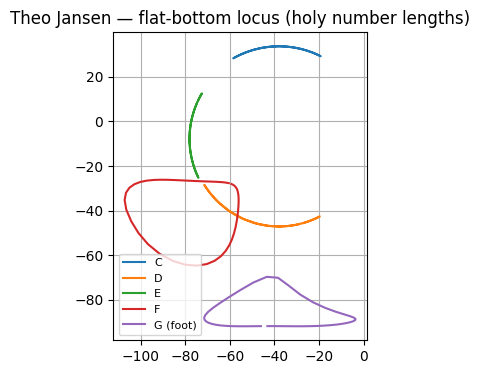

In [3]:
jansen = ls.Walker.from_jansen()
print(f'DOF: {jansen.dof}, feet: {jansen.get_feet()}')

fig, ax = plt.subplots(figsize=(7, 4))
for name, xs, ys in foot_loci(jansen):
    ax.plot(xs, ys, label=name)
ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8)
ax.set_title("Theo Jansen — flat-bottom locus (holy number lengths)")
plt.show()


## 3. Klann's 6-bar (US Patent 6,260,862)

Klann's linkage (6 links, one crank) approximates a scissor-gait pattern
with fewer parts than Jansen's. The foot lifts higher in swing — useful
for stepping over obstacles but worse for body stability.


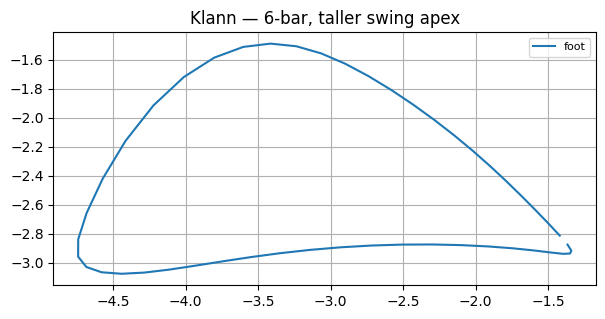

In [4]:
klann = ls.Walker.from_klann()

fig, ax = plt.subplots(figsize=(7, 4))
for name, xs, ys in foot_loci(klann):
    ax.plot(xs, ys, label=name)
ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8)
ax.set_title("Klann — 6-bar, taller swing apex")
plt.show()


## 4. Chebyshev's lambda (4-bar, 1850s)

The simplest mechanism here: a **four-bar** with a coupler point. The
foot traces an approximate straight line on the lower half of the
cycle, and a shallow arc on the upper half. Four bars is the minimum
for a 1-DOF single-leg mechanism.


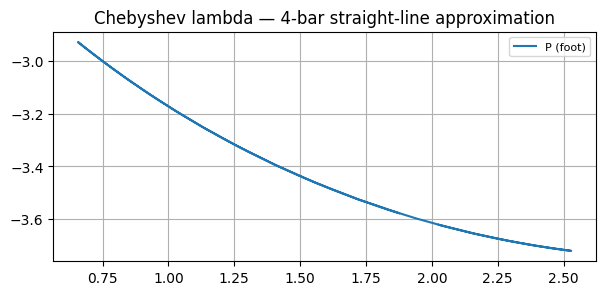

In [5]:
cheb = ls.Walker.from_chebyshev()

fig, ax = plt.subplots(figsize=(7, 4))
for name, xs, ys in foot_loci(cheb):
    ax.plot(xs, ys, label=name)
ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8)
ax.set_title("Chebyshev lambda — 4-bar straight-line approximation")
plt.show()


## 5. Strider (Vagle / DIY Walkers)

Strider is a symmetric 10-bar popularized by Wade Vagle — two mirrored
four-bar stacks driven from a shared crank. It's the mechanism that
`sandbox_legged.py` at the monorepo root optimizes. Its default
rotation period is small (10 frames), so we pass a higher iteration
count for a smooth curve.


/tmp/ipykernel_105579/1582669532.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=7, ncol=2)


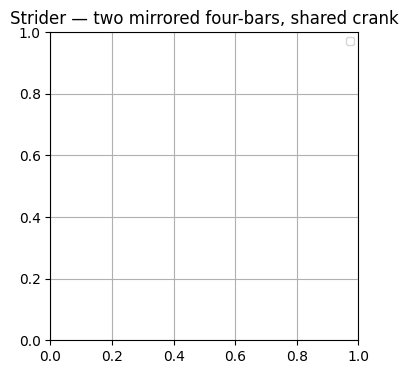

In [6]:
strider = ls.Walker.from_strider()

fig, ax = plt.subplots(figsize=(7, 4))
for name, xs, ys in foot_loci(strider, iterations=120):
    ax.plot(xs, ys, label=name)
ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=7, ncol=2)
ax.set_title("Strider — two mirrored four-bars, shared crank")
plt.show()


## 6. Ghassaei's 5-dyad (2011 Pomona thesis)

Amanda Ghassaei's leg is a five-RRR-dyad chain driven by a single
crank. `Walker.from_ghassaei()` uses the thesis's classical dimensions
(crank=26, ground=53, inner=56, outer=77, closing=75, H→E arm=130).
The H→E arm length is not given on Figure 5.4.4 and is tuned here to
reproduce the Wikibooks Walkin8r foot-locus aspect (x:y ≈ 1:0.24).


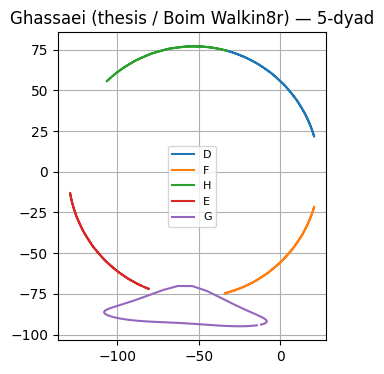

In [7]:
ghassaei = ls.Walker.from_ghassaei()

fig, ax = plt.subplots(figsize=(7, 4))
for name, xs, ys in foot_loci(ghassaei):
    ax.plot(xs, ys, label=name)
ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8)
ax.set_title("Ghassaei (thesis / Boim Walkin8r) — 5-dyad")
plt.show()


## 7. Watt and Stephenson six-bars

The two six-bar families. Both open richer foot-path geometries than
a pure four-bar — classical synthesis gives them for coupler-curve
targets that the 4-bar cannot reach. `Walker.from_watt()` and
`Walker.from_stephenson()` take explicit link lengths (no factory
defaults yet); we pass sensible starting values below.


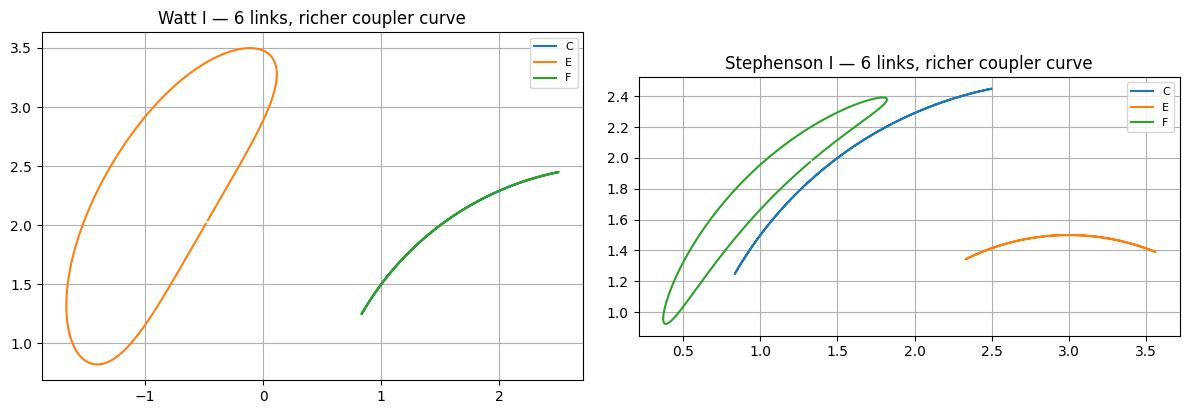

In [8]:
watt = ls.Walker.from_watt(
    crank=1.0, coupler1=2.5, rocker1=2.5,
    link4=2.5, link5=2.5, rocker2=2.5,
    ground_length=3.0,
)
stephenson = ls.Walker.from_stephenson(
    crank=1.0, coupler=2.5, rocker=2.5,
    link4=1.5, link5=1.5, link6=2.0,
    ground_length=3.0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, title, walker in [(axes[0], "Watt I", watt), (axes[1], "Stephenson I", stephenson)]:
    for name, xs, ys in foot_loci(walker):
        ax.plot(xs, ys, label=name)
    ax.set_aspect('equal'); ax.grid(True); ax.legend(fontsize=8)
    ax.set_title(f"{title} — 6 links, richer coupler curve")
plt.tight_layout(); plt.show()


## Summary

| Mechanism   | Links | Defining property                          |
|-------------|-------|--------------------------------------------|
| Chebyshev   | 4     | Simplest — straight-line approximation     |
| Klann       | 6     | Scissor-gait, high swing apex              |
| Watt I      | 6     | Inline coupler, double-dwell curves         |
| Stephenson  | 6     | Branched coupler, wider coupler-curve space |
| Jansen      | 8     | Flat-bottom stance (Jansen's "holy number") |
| Strider     | 10    | Mirrored four-bars, symmetric gait          |
| Ghassaei    | 12    | Five-dyad chain, broad horizontal stride    |

Pick a factory as a starting point, then tune link lengths with the
optimization pipeline (notebook 03) or swap topologies entirely with
`topology_walking_optimization` (see `discover_walker.ipynb`).
